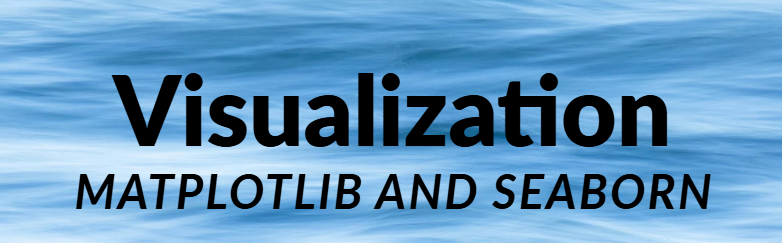

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [Plot Function](#plotfunction)
3. [Line chart](#linechart)
4. [Bar chart](#barchart)
5. [Histogram](#histogram)
6. [Boxplot](#boxplot)
7. [Scatter plot](#scatterplot)
8. [Exercise](#exercise)

<div class="alert alert-warning">
    <b> I. <i>Introduction </i></b>
    <a id="introduction"></a>

Pandas provides built-in functionality to visualize data stored in DataFrames and Series. These plotting capabilities rely on the ``Matplotlib`` library, which acts as the underlying engine for all graphical representations.

Data visualization with Pandas is very practical due to its ease of use, and it will serve us for interpreting the data we have processed and for creating reports.

Pandas charts are an abstraction of the matplotlib library, which allows us to create some charts easily. If we need to create more complex charts, we can use the tools that matplotlib provides.However, this typically requires more detailed code.

In addition to Matplotlib, we will also explore ``Seaborn``, a modern visualization library and complements pandas very well.

Although data visualization offers a wide range of possibilities, this section will focus on the most common chart types and the essential elements for clear interpretation, such as titles, axis labels, tick formatting, legends, and color schemes.

You can consult the official documentation of the libraries here:
- [Pandas Visualization Guide](https://pandas.pydata.org/docs/user_guide/visualization.html) 
- [Matplotlib documentation](https://matplotlib.org/stable/users/index.html)
- [Seaborn Homepage](https://seaborn.pydata.org/)

__📚Matplotlib library__

As mentioned above, ``Matplotlib`` is the core library used by Pandas to generate plots. It provides a powerful and flexible framework for creating a wide variety of advanced visualizations and define the components of a plot internally.

Using Matplotlib directly allows for greater customization and control over every aspect of a chart, including layout, colors, annotations, and export options.

__📚Seaborn library__

``Seaborn`` is a Python data visualization library. It is designed to simplify the creation of statistical graphics and improve their visual appearance by default (create attractive and informative statistical charts).

It provides an intuitive interface for generating common plots such as histograms, box plots, scatter plots, and heatmaps, with enhanced styling and built-in themes.

Before using ``Seaborn``, it must be installed:

In [ ]:
%pip install seaborn

Then, we can import the necessary libraries:

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcdefaults()

<div class="alert alert-warning">
    <b> II. <i>Plot function </i></b>
    <a id="plotfunction"></a></div>

The ``plot()`` function in Pandas is the main and simplest way to create visualizations directly from a DataFrame or a Series.

We can simulate data with ``numpy`` and visualize it: 

In [41]:
np.random.seed(1)
samples = 50

df = pd.DataFrame({ 
    "Temperature":np.random.randint(low=-10,high=50,size=samples),
    "Rain":np.random.randint(low= 0,high=50,size=samples),
    "Wind":np.random.choice(["N","S","E","W"],size=samples)})

df.head()

,Temperature,Rain,Wind
0,27,42,W
1,33,8,N
2,2,30,E
3,-2,7,E
4,-1,3,E


__Basic Usage__

Pandas Automatically selects numeric columns, uses the index as X-axis and plots all columns as line charts.

```
df.plot()
```

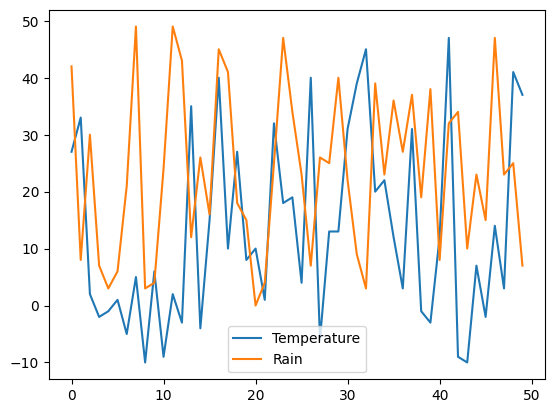

In [42]:
df.plot();

The function has created multiple lines, one per numeric column (Temperature and Rain), while non-numeric columns like ``Wind`` are ignored.

__Dataframe vs Series__

Previously, we drew all the numeric variables from a dataframe in the same plot. By selecting a numeric variable, we can plot a single line for that variable. 

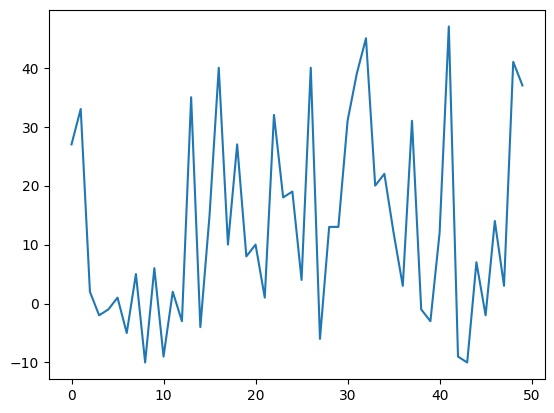

In [43]:
df.Temperature.plot();

What happens when we try to plot the ``Wind`` column?

In [44]:
#df.Wind.plot()

We can aggregate first: 

In [45]:
df.groupby(["Wind"]).count()

,Temperature,Rain
Wind,,
E,9,9
N,16,16
S,12,12
W,13,13


Now, we have categories and numeric values and we can plot:

<Axes: xlabel='Wind'>

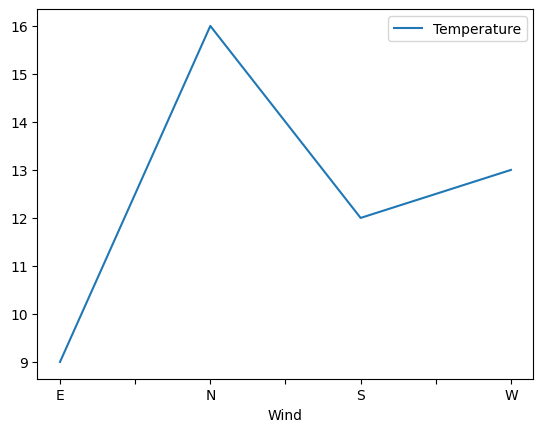

In [46]:
df[["Wind","Temperature"]].groupby(["Wind"]).count().plot()

__The `kind` parameter__

This parameter is used to control the type of chart displayed. The available options include:

- __bar__: vertical bar chart
- __barh__: horizontal bar chart
- __hist__: histogram
- __box__: box plot
- __area__: area plot
- __pie__: pie chart
- __scatter__: scatter plot (DataFrame only)
- __hexbin__: hexbin plot (DataFrame only)

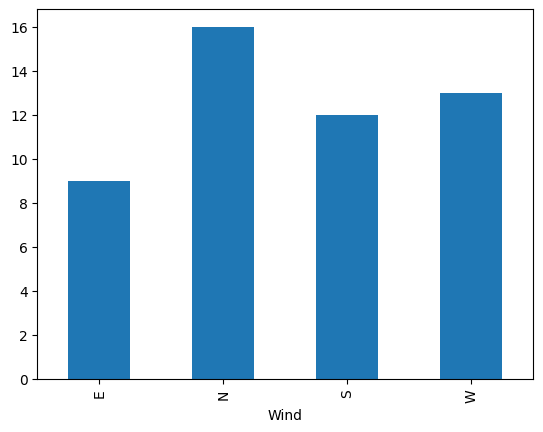

In [47]:
df.groupby(["Wind"]).size().plot(kind="bar");

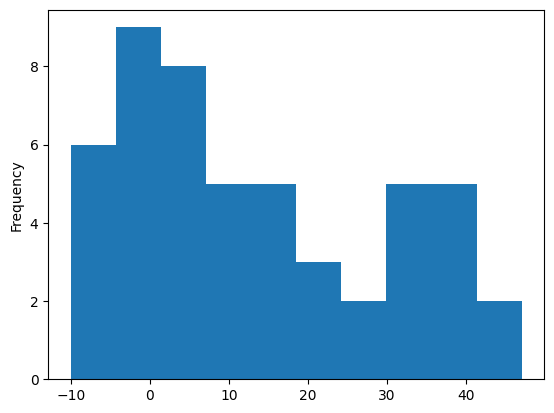

In [48]:
df.Temperature.plot(kind="hist");

In addition to the plot type, the `plot` function allows us to define other characteristics of the plot using several parameters:

- __title__: allows you to define the plot's title using a String.
- __legend__: a boolean that indicates whether or not the plot has a legend.
- __xlabel__: label for the x-axis.
- __ylabel__: label for the y-axis.
- __colormap__: color map to use for plotting. [More Info](https://matplotlib.org/stable/users/explain/colors/colormaps.html).


This function has several other parameters that we can consult in its [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

Let's see how we can add some information to our graph:

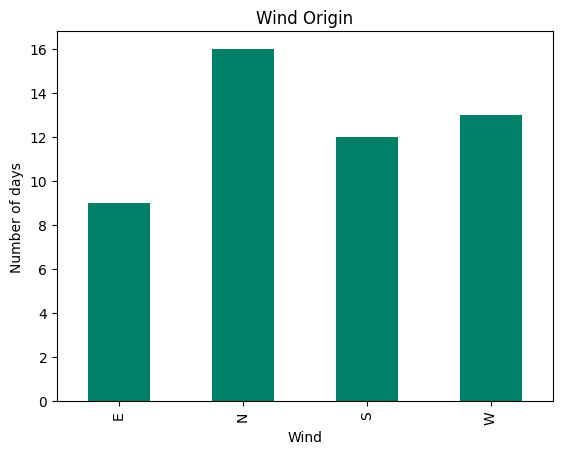

In [49]:
df.groupby(["Wind"]).size().plot(
    kind="bar", 
    title="Wind Origin",
    ylabel="Number of days", 
    colormap="summer"
);

<div class="alert alert-warning">
    <b> III. <i>Line chart </i></b>
    <a id="linechart"></a></div>

A line chart is used to visualize how a variable changes over time or across an ordered sequence.

__Plot function__

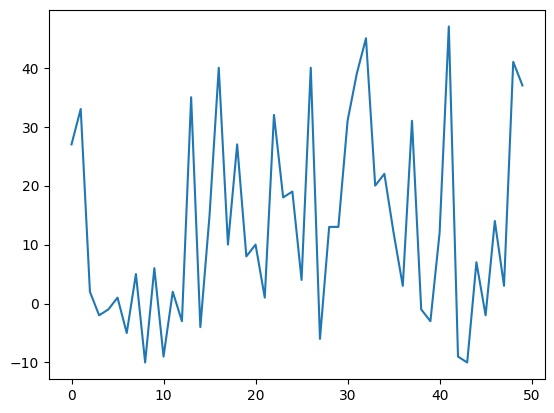

In [50]:
df["Temperature"].plot();

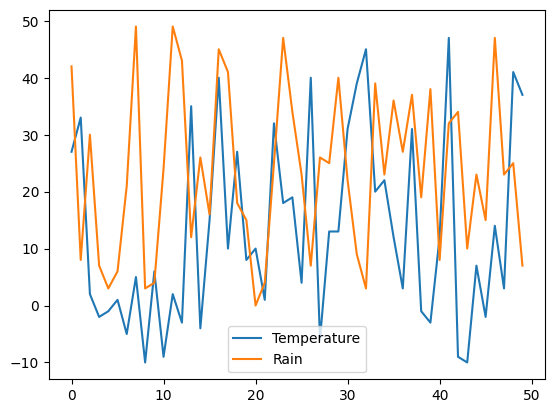

In [51]:
df.plot();

__Matplotlib__

With matplotlib we need to define the form of the plot. We can do this with ``subplots``. This function returns two objects: the figure, which is the container of the plot and controls the size, layout and if there are multiple plots; and the axes, which contains where the data is drawn. 

With ``plot`` we can define the data. Additionally, we can define: 
- __color__: line color. 
- __linestyle__: type of line. 
- __linewidth__: thickness of the line. 

In case we draw a scatter plot: 
- __marker__: the style of the point. 
- __markersize__: the size of the markers. 

We can put a title and labels to each axis: 

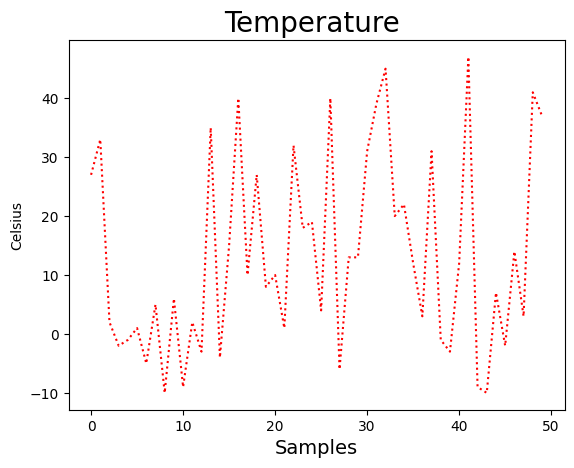

In [52]:
fig, ax = plt.subplots()

ax.plot(df["Temperature"], color ='red', linestyle='dotted') 

plt.title("Temperature ", fontsize=20) 
plt.xlabel('Samples', fontsize=14)
plt.ylabel('Celsius')

#plt.savefig('data/test.png',dpi=100) # guardat
plt.show()

We can also draw more than one line: 

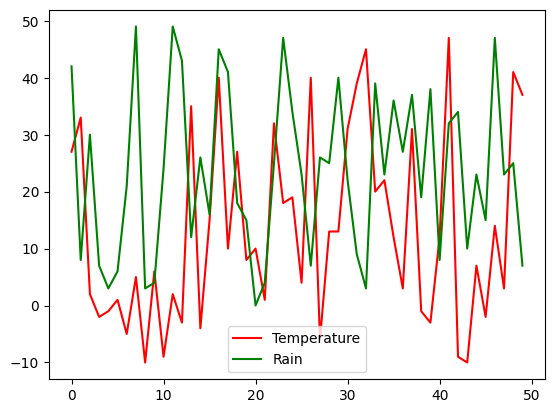

In [53]:
fig, ax = plt.subplots()

ax.plot(df["Temperature"], label="Temperature", color = 'red')
ax.plot(df["Rain"], label="Rain", color = 'green')

plt.legend()
plt.show()

__Seaborn__

We use ``lineplot`` to create a line chart using ``Seaborn``. 
This are the most important parameters: 

- __data__: a Pandas dataframe. 
- __x__ and __y__: what data goea on each axis. 
- __hue__: splits data into lines by color. 
- __style__: changes line pattern.
- __size__: changes line thickness. 
- __palette__: we can select the colors used for ``hue``. 

<Axes: xlabel='None', ylabel='Temperature'>

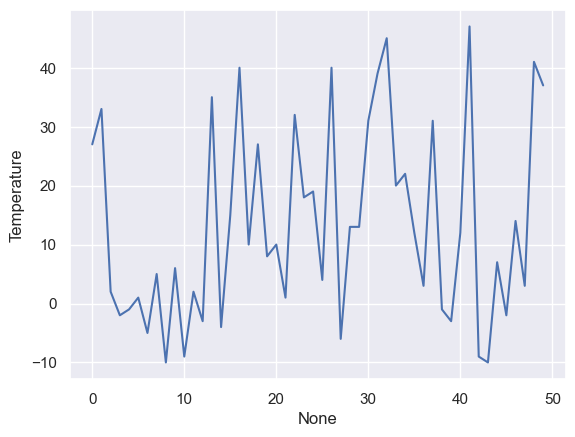

In [54]:
sns.set_theme() # This allows us to put a background theme.
sns.lineplot(data=df, x=df.index, y="Temperature")

We can also load datasets. ``flights`` is a dataset that has 10 years of monthly airline passenger data. 

In [55]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<div class="alert alert-info">

__Mini Activity__
- Apply ``hue`` by month. 
- Apply ``style`` by month.

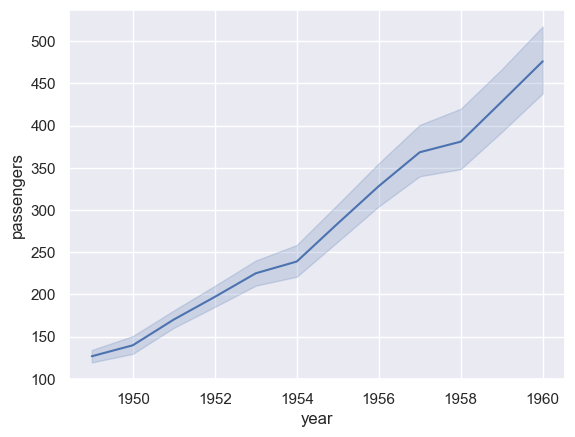

In [56]:
sns.lineplot(
    data=flights,
    x="year",
    y="passengers"
)
plt.show()

<div class="alert alert-warning">
    <b> IV. <i>Barchart </i></b>
    <a id="barchart"></a>

__Plot function__

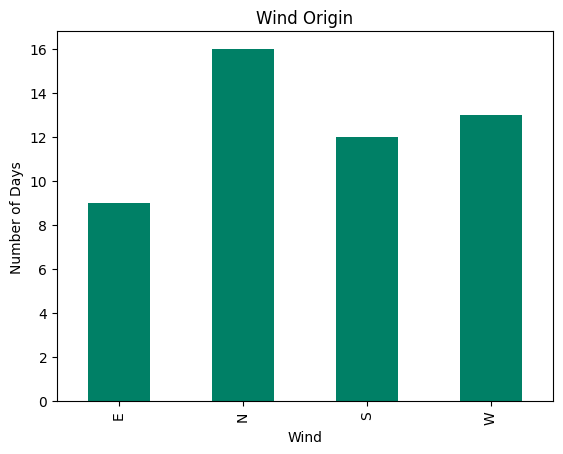

In [57]:
plt.rcdefaults()
df.groupby(["Wind"]).size().plot(
    kind="bar", 
    title="Wind Origin", 
    ylabel="Number of Days", 
    colormap="summer"
    );


__Matplotlib__

Let's see how to plot a bar chart using ``Matplotlib``. 
Let's make the previous plot:


In [58]:
windType  = df.groupby(["Wind"]).size()
print(windType)

Wind
E     9
N    16
S    12
W    13
dtype: int64


In order to plot a bar chart, we need the values of the __x__ and __y__ axis:

In [59]:
x = windType.index
y = windType.values
print("x: ", windType.index)
print("y: ", windType.values)


x:  Index(['E', 'N', 'S', 'W'], dtype='object', name='Wind')
y:  [ 9 16 12 13]


To create a bar chart, we use the functon ``bar``: 
- __x__ and __y__:  indicating the categories and height of each bar. 
- __color__: list of colors, indicating one per bar. 

``set_xticks``: set where the labels go.
``set_xticklabels``: Set the text labels on x-axis.
``set_y_label``: Set the label for y-axis.


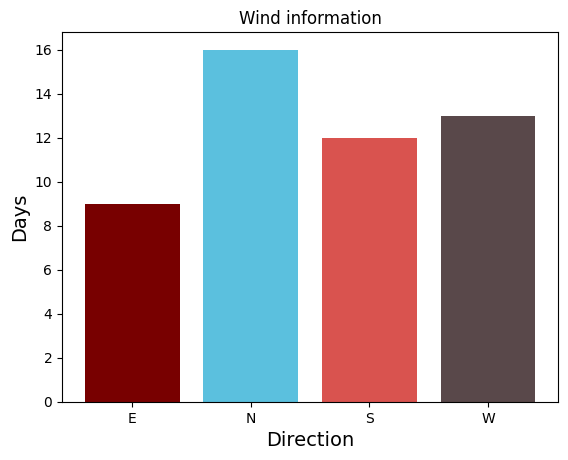

In [60]:
fig, ax = plt.subplots() 

ax.bar(x, y, color=['#780000','#5bc0de','#d9534f','#59484a']) 
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_ylabel("count");
plt.title("Wind information"); # Put a title
plt.xlabel('Direction', fontsize=14); # Put a label indicating what is the x axis
plt.ylabel('Days', fontsize=14); # put a label indicating what is the y-axis
plt.show();

We can combine both libraries (plot function and matplotlib):

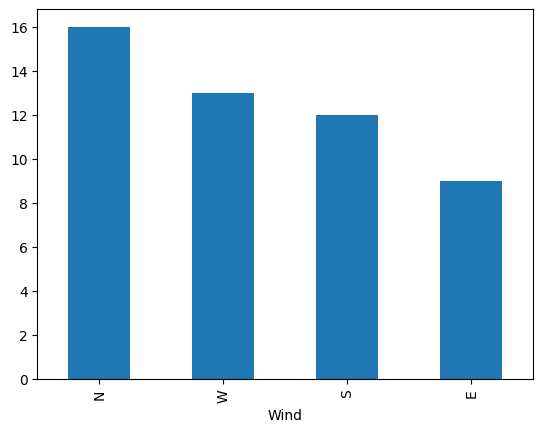

In [61]:
wind =windType.sort_values(ascending=False)
ax = wind.plot(kind="bar")
plt.show()

__Seaborn__

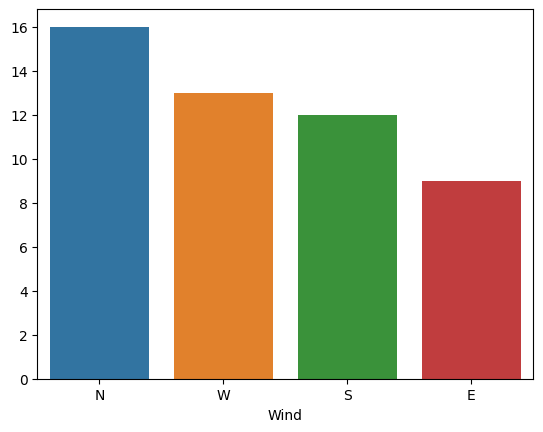

In [62]:
wind = windType.sort_values(ascending=False)
ax = sns.barplot(x=wind.index, y=wind.values, hue=wind.index)
plt.show()

<div class="alert alert-warning">
    <b> V. <i>Histogram </i></b>
    <a id="histogram"></a>

__Plot__

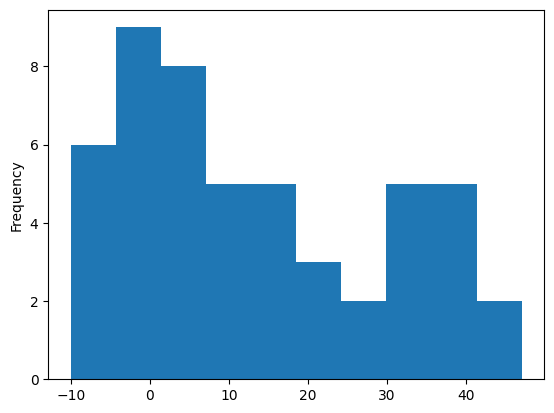

In [63]:
df.Temperature.plot(kind="hist");

__Matplotlib__

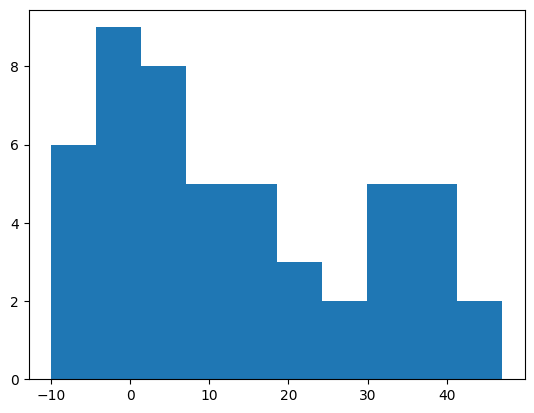

In [64]:
temp = df["Temperature"]
fig, ax = plt.subplots()
ax.hist(temp.values,bins=10) # we need to put the number of bins 
plt.show()

__Seaborn__

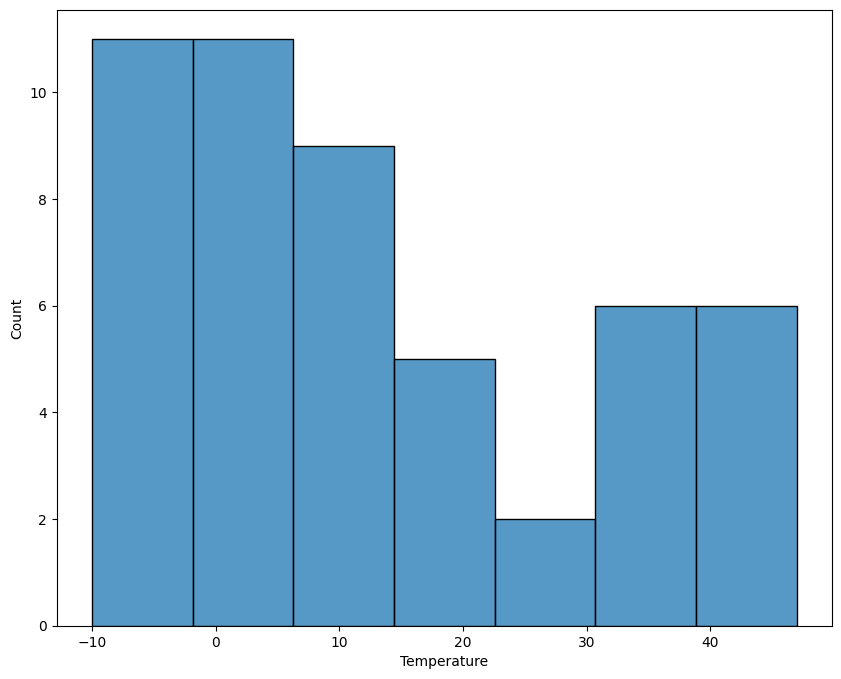

In [65]:
fig, ax = plt.subplots(figsize=(10, 8)) # we can put the size
sns.histplot(df, x="Temperature", ax=ax)
plt.show()

<div class="alert alert-info">

__Mini Exercise__
1. Read WHO.csv. 
2. Create a histogram with Seaborn of ``LiteracyRate``. 
3. Add ``hue`` by continent. 
5. Now use the column ``TotalExpenditureHealth``. Use parameter ``multiple`` to create a stack bar chart.

<div class="alert alert-warning">
    <b> VI. <i>Boxplot </i></b>
    <a id="boxplot"></a>

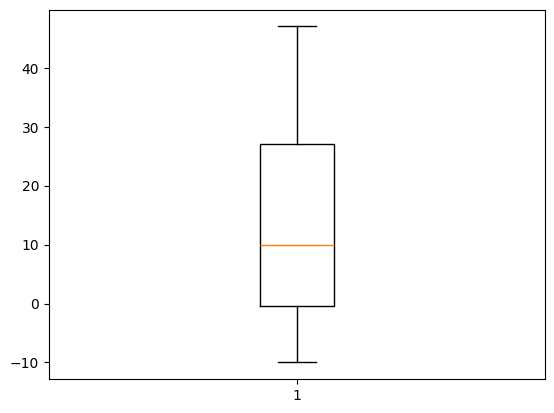

In [66]:
temp = df["Temperature"]
fig, ax = plt.subplots() 
ax.boxplot(temp.values)
plt.show()

We can define more than one plot together putting the number of columns in the function ``subplots``. 

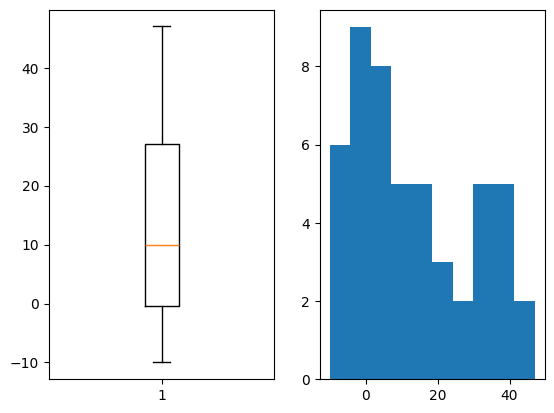

In [67]:
temp = df["Temperature"]
fig, ax = plt.subplots(ncols=2)
ax[0].boxplot(temp.values)
ax[1].hist(temp)

plt.show()

<div class="alert alert-warning">
    <b> VII. <i>Scatter plot </i></b>
    <a id="scatterplot"></a>

__Plot function__

<Axes: xlabel='Temperature', ylabel='Rain'>

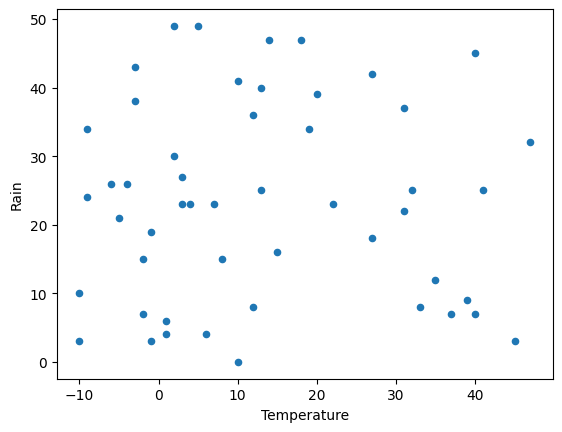

In [68]:
df.plot(kind="scatter", x="Temperature", y="Rain")

__Matplotlib__

We can simulate a scatter plot and use the function ``scatter``. 
- __c__: controls the color of the points. 
- __alpha__: controls the transparency. 

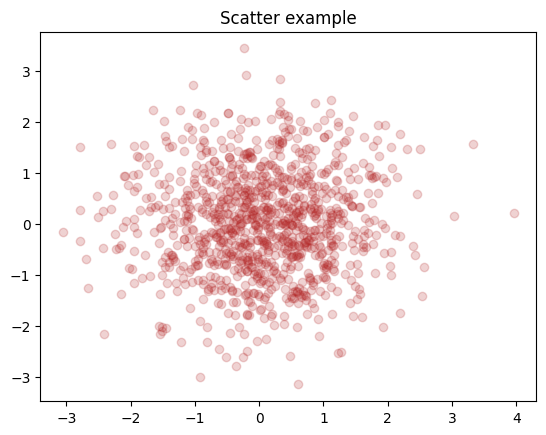

In [69]:
x = np.random.normal(size=1000)
y = np.random.normal(size=1000)

plt.scatter(x, y, c='firebrick', alpha=0.2)
plt.title("Scatter example")
plt.show()

__Seaborn__

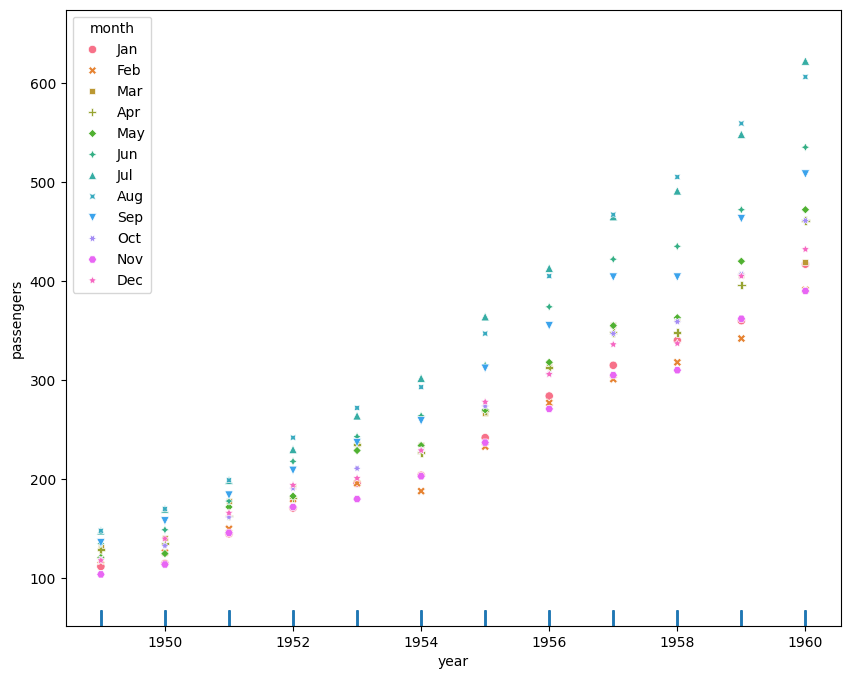

In [74]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=flights, x="year", y="passengers",hue="month", style="month")
sns.rugplot(data=flights, x="year")
plt.show()

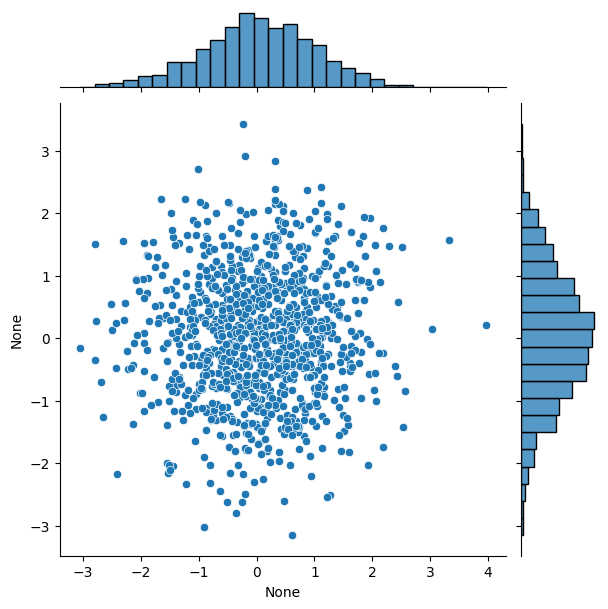

In [71]:
sns.jointplot(x=x, y=y)

<div class="alert alert-warning">
    <b> VIII. <i>Exercise </i></b>
    <a id="exercise"></a>

<div class="alert alert-info">

1. Read WHO.csv. 
2. Display a chart with the 10 most populous countries (“Population (in thousands) total”). 
3. Remove NAN values. 

<div class="alert alert-info">

4. Plot a boxplot of Europe's pollution (CO2) (CO2_emissions) (continent code: 2) 

<div class="alert alert-info">

4. Plot a boxplot of Europe's pollution (CO2) (CO2_emissions) (continent code: 2) 

<div class="alert alert-info">

5. Use tips dataset from seaborn. 
6. Plot the distribution of total bill and days.

<div class="alert alert-info">

6. Plot the distribution of total bill, days and sex.
7.  Plot the distribution of total bill, days and smoker.